# code for event segmentation procedure

Adapted from Heuser et al., 2018: https://github.com/ContextLab/sherlock-topic-model-paper/blob/master/code/notebooks/main/eventseg_analysis.ipynb

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import brainiak.eventseg.event as event
import pickle
import os
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### some paths

In [2]:
annot_dir = '../../data/annotations_dfs/'
model_dir = '../../data/models/episodes/t100_w50/'
transc_dir = '../../data/transcriptions/automatic/'
pickle_dir = '../../data/pickles/'

## load episode models

In [3]:
atlep1_model = np.load(model_dir+'/atlep1_model_t100_w50_res.npy')
atlep2_model = np.load(model_dir+'/atlep2_model_t100_w50_res.npy')
arrdev_model = np.load(model_dir+'/arrdev_model_t100_w50_res.npy')
ep_models_dict = {'atlep1': atlep1_model, 'atlep2' : atlep2_model, 'arrdev' : arrdev_model}

FileNotFoundError: [Errno 2] No such file or directory: '../../data/models/episodes/t100_w50//atlep1_model_t100_w50_res.npy'

## load participant models

In [4]:
with open(pickle_dir+'/participant_models.p', 'rb') as f:
    participant_models = pickle.load(f)

## find optimal k for each episode model

In [5]:
# ep_model_ks = {'atlep1' : [], 'atlep2': [], 'arrdev' : []}

# for ep_model, key in zip([atlep1_model, atlep2_model, arrdev_model], ep_model_ks.keys()):
    
#     corrmat = np.corrcoef(ep_model)
    
#     for n_events in range(1, 51):
#         print('fitting '+ key + ' to ' + str(n_events) + ' events...')
#         ev = event.EventSegment(n_events)
#         ev.fit(ep_model)
#         roundedmat = np.round(ev.segments_[0]).astype(int)
#         mask = np.sum(list(map(lambda x: np.outer(x, x), roundedmat.T)), 0).astype(bool)
#         within = corrmat[mask].mean()
#         across = corrmat[~mask].mean()
#         ep_model_ks[key].append((within, across, within/across))
        

In [6]:
# with open(pickle_dir+'/ep_model_ks.p', 'wb') as f:
#     pickle.dump(ep_model_ks, f)

In [5]:
with open(pickle_dir+'/ep_model_ks.p', 'rb') as f:
    ep_model_ks = pickle.load(f)

## plot within- & across-event correlations as a function of k

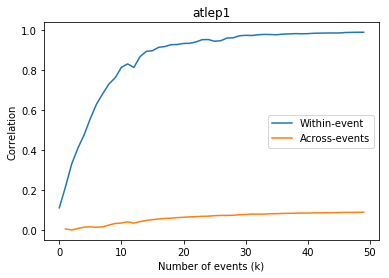

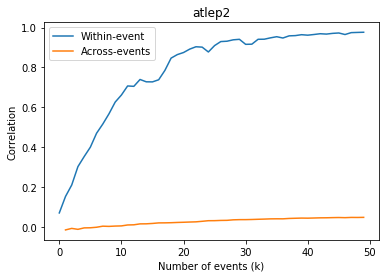

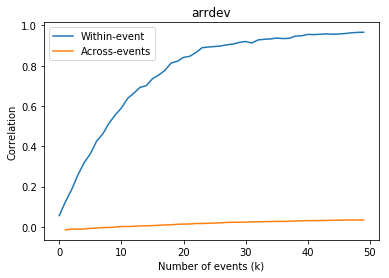

In [6]:
for ep, ks in ep_model_ks.items():
    plt.plot(list(map(lambda x: x[0], ks)), label='Within-event')
    plt.plot(list(map(lambda x: x[1], ks)), label='Across-events')
    plt.title(ep)
    plt.legend()
    plt.xlabel('Number of events (k)')
    plt.ylabel('Correlation')
    plt.show()

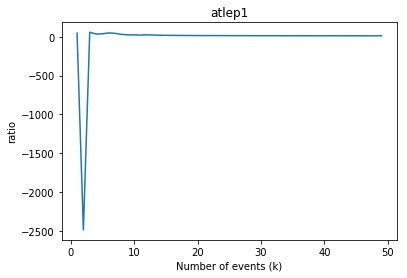

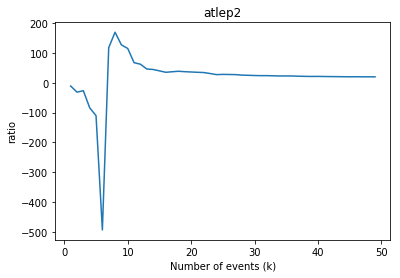

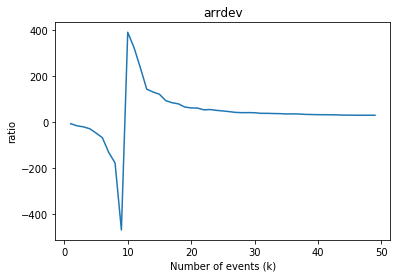

In [7]:
for ep, ks in ep_model_ks.items():
    plt.plot(list(map(lambda x: x[2], ks)))
    plt.title(ep)
    plt.xlabel('Number of events (k)')
    plt.ylabel('ratio')
    plt.show()

## plot ratio of within- & across-event correlations as a function of k

atlep1: Max ratio at 32 events


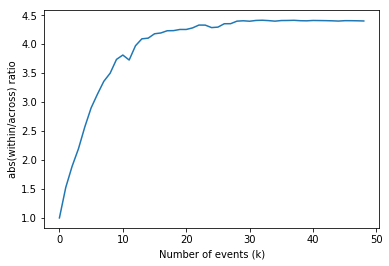

atlep2: Max ratio at 27 events


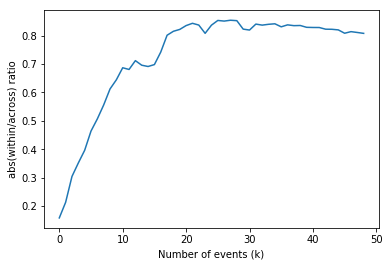

arrdev: Max ratio at 29 events


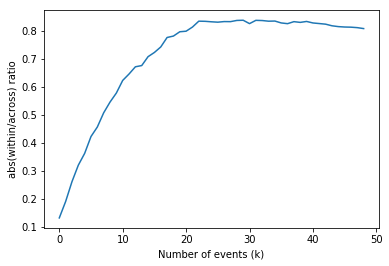

In [72]:
ep_max_ks = []
for ep, ks in ep_model_ks.items():
#     t=list(map(lambda x: x[0]/(x[1]-min(ks[1])), ks))[1:]
    t=list(map(lambda x: x[0]/(x[1]-ks[1][2]), ks))[1:]
    t/=np.max(t)
    
    for i, v in enumerate(t):
        t[i]-=i/250    # regularization parameter (5 x episode_wsize)
    
    plt.plot(t)
    plt.ylabel('abs(within/across) ratio')
    plt.xlabel('Number of events (k)')
    print(ep + ': Max ratio at ' + str(np.argmax(t)) + ' events')
    ep_max_ks.append((ep, np.argmax(t)))
    plt.show()

atlep1: Max ratio at 0 events


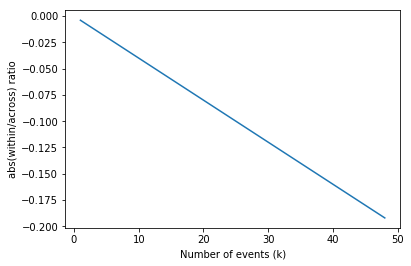

atlep2: Max ratio at 27 events


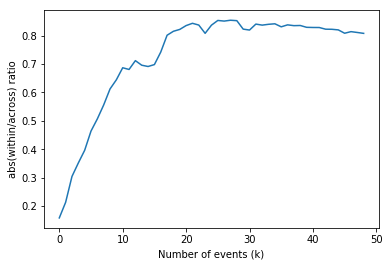

arrdev: Max ratio at 29 events


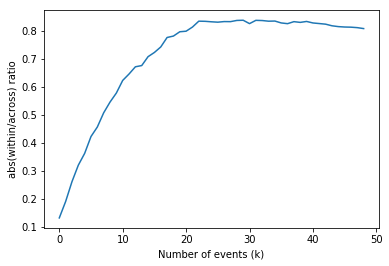

In [8]:
ep_max_ks = []
for ep, ks in ep_model_ks.items():
#     t=list(map(lambda x: x[0]/(x[1]-min(ks[1])), ks))[1:]
    t=list(map(lambda x: x[0]/(x[1]-ks[1][2]), ks))[1:]
    t/=np.max(t)
    
    for i, v in enumerate(t):
        t[i]-=i/250    # regularization parameter (5 x episode_wsize)
    
    plt.plot(t)
    plt.ylabel('abs(within/across) ratio')
    plt.xlabel('Number of events (k)')
    print(ep + ': Max ratio at ' + str(np.argmax(t)) + ' events')
    ep_max_ks.append((ep, np.argmax(t)))
    plt.show()

## fit eventseg model with optimal k to each, save eventseg model, save segmented episode model, save onset/offset times for each event (midpoint time of 1st/last annotation in each event)

In [6]:
def reduce_model(m, ev):
    """
    Reduce a model based on event labels
    """
    w = (np.round(ev.segments_[0])==1).astype(bool)
    return np.array([m[wi, :].mean(0) for wi in w.T])

In [99]:
# for ep_name, max_k in ep_max_ks:
#     ev = event.EventSegment(max_k)
#     ev.fit(ep_models_dict[ep_name])
#     episode_events = reduce_model(ep_models_dict[ep_name], ev)
    
#     # save episodes' fit eventseg models
#     with open(pickle_dir+'/eventseg-models/{}_eventseg_model.p'.format(ep_name), 'wb') as f:
#         pickle.dump(ev, f)
    
#     # save segmented episode models
#     np.save(model_dir+'/{}_events'.format(ep_name), episode_events)
    
#     event_onsets_offsets = []
    
#     # get onset/offset times
#     for s in ev.segments_[0].T:
#         tpts = np.where(np.round(s)==1)[0]
#         event_onsets_offsets.append((tpts[0], tpts[-1]))
        
#     # save onset/offset times
#     with open(pickle_dir+'/eventseg-models/{}_event_times.p'.format(ep_name), 'wb') as f:
#         pickle.dump(event_onsets_offsets, f)

## find optimal k for each recall model (split between other eventseg notebooks)

In [82]:
participant_max_ks = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'prediction' : [],
                     'delayed' : []}

In [12]:
ks = list(range(2,38))

for a_type, participants in participant_models.items():
    if a_type == 'atlep1':
        for participant in participants[:len(participants)//2]:
            turkid, model = participant[0], participant[1]
            print('fitting ' + turkid + '...')
            mcorr = np.corrcoef(model)
            cs = []
            for k in ks:
                print('\tk = ' + str(k))
                ev = event.EventSegment(k)
                ev.fit(model)
                i1, i2 = np.where(np.round(ev.segments_[0])==1)
                w = np.zeros_like(ev.segments_[0])
                w[i1,i2] = 1
                w = np.dot(w, w.T).astype(bool)
                c = mcorr[w].mean()/mcorr[~w].mean() - k/50
                cs.append(c)
            m = ks[np.argmax(cs)]
            participant_max_ks[a_type].append((turkid, m))

fitting debugQ0oPh:debugCquQc...
	k = 2
	k = 3
	k = 4
	k = 5
	k = 6
	k = 7
	k = 8
	k = 9
	k = 10
	k = 11
	k = 12
	k = 13
	k = 14
	k = 15
	k = 16
	k = 17
	k = 18
	k = 19
	k = 20
	k = 21
	k = 22
	k = 23
	k = 24
	k = 25
	k = 26
	k = 27
	k = 28
	k = 29
	k = 30
	k = 31
	k = 32
	k = 33
	k = 34
	k = 35
	k = 36
	k = 37
fitting debugmFRWe:debug4RZkW...
	k = 2
	k = 3
	k = 4
	k = 5
	k = 6
	k = 7
	k = 8
	k = 9
	k = 10
	k = 11
	k = 12
	k = 13
	k = 14
	k = 15
	k = 16
	k = 17
	k = 18
	k = 19
	k = 20
	k = 21
	k = 22
	k = 23
	k = 24
	k = 25
	k = 26
	k = 27
	k = 28
	k = 29
	k = 30
	k = 31
	k = 32
	k = 33
	k = 34
	k = 35
	k = 36
	k = 37
fitting debug92cgv:debugvdAIT...
	k = 2
	k = 3
	k = 4
	k = 5
	k = 6
	k = 7
	k = 8
	k = 9
	k = 10
	k = 11
	k = 12
	k = 13
	k = 14
	k = 15
	k = 16
	k = 17
	k = 18
	k = 19
	k = 20
	k = 21
	k = 22
	k = 23
	k = 24
	k = 25
	k = 26
	k = 27
	k = 28
	k = 29
	k = 30
	k = 31
	k = 32
	k = 33
	k = 34
	k = 35
	k = 36
	k = 37
fitting debugYQfMB:debugxg7il...
	k = 2
	k = 3
	k = 4
	k = 5


	k = 6
	k = 7
	k = 8
	k = 9
	k = 10
	k = 11
	k = 12
	k = 13
	k = 14
	k = 15
	k = 16
	k = 17
	k = 18
	k = 19
	k = 20
	k = 21
	k = 22
	k = 23
	k = 24
	k = 25
	k = 26
	k = 27
	k = 28
	k = 29
	k = 30
	k = 31
	k = 32
	k = 33
	k = 34
	k = 35
	k = 36
	k = 37
fitting debugHKLdw:debugk43rK...
	k = 2
	k = 3
	k = 4
	k = 5
	k = 6
	k = 7
	k = 8
	k = 9
	k = 10
	k = 11
	k = 12
	k = 13
	k = 14
	k = 15
	k = 16
	k = 17
	k = 18
	k = 19
	k = 20
	k = 21
	k = 22
	k = 23
	k = 24
	k = 25
	k = 26
	k = 27
	k = 28
	k = 29
	k = 30
	k = 31
	k = 32
	k = 33
	k = 34
	k = 35
	k = 36
	k = 37
fitting debugpdN5k:debug3flgN...
	k = 2
	k = 3
	k = 4
	k = 5
	k = 6
	k = 7
	k = 8
	k = 9
	k = 10
	k = 11
	k = 12
	k = 13
	k = 14
	k = 15
	k = 16
	k = 17
	k = 18
	k = 19
	k = 20
	k = 21
	k = 22
	k = 23
	k = 24
	k = 25
	k = 26
	k = 27
	k = 28
	k = 29
	k = 30
	k = 31
	k = 32
	k = 33
	k = 34
	k = 35
	k = 36
	k = 37


In [77]:
atlep1_max_ks = participant_max_ks['atlep1']

with open(pickle_dir+'/eventseg-models/tmp-parallel-output/atlep1_max_ks.p', 'wb') as f:
    pickle.dump(atlep1_max_ks, f)

## load in all optimal k results & combine

In [84]:
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(pickle_dir+'/eventseg-models/tmp-parallel-output/'+rectype+'_max_ks.p', 'rb') as f:
        partial_k = pickle.load(f)
    try:
        with open(pickle_dir+'/eventseg-models/tmp-parallel-output/'+rectype+'_max_ks-1.p', 'rb') as f:
            partial_k1 = pickle.load(f)
    except:
        partial_k1 = []
    
    participant_max_ks[rectype] = partial_k + partial_k1

## segment participant models into optimal k events, get onset/offset times, save models

In [104]:
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for rectype, data in participant_models.items():
    for (turkid, rec_model) in data:
        for tid, k in participant_max_ks[rectype]:
            if turkid == tid:
                print('fitting ' + turkid + ' ' + rectype + ' model, k = ' + str(k))
                ev = event.EventSegment(k)
                ev.fit(model)
                recall_events = reduce_model(model, ev)
                participant_events[rectype].append((turkid, recall_events))

                # save segmented model
                np.save('../../data/models/recall/{0}/{1}_events'.format(rectype, turkid), recall_events)
                
                # save fit eventseg model
                with open('../../data/models/recall/{0}/{1}_eventseg_model.p'.format(rectype, turkid), 'wb') as f:
                    pickle.dump(ev, f)
                    
                event_onsets_offsets = []
                
                # get event onset/offset times
                for s in ev.segments_[0].T:
                    tpts = np.where(np.round(s)==1)[0]
                    event_onsets_offsets.append((tpts[0], tpts[-1]))
                    
                # save onset/offset times
                with open('../../data/models/recall/{0}/{1}_event_times.p'.format(rectype, turkid), 'wb') as f:
                    pickle.dump(event_onsets_offsets, f)
                    

fitting debugQ0oPh:debugCquQc atlep1 model, k = 12
fitting debugmFRWe:debug4RZkW atlep1 model, k = 9
fitting debug92cgv:debugvdAIT atlep1 model, k = 11
fitting debugYQfMB:debugxg7il atlep1 model, k = 3
fitting debughbxU4:debugUuTk6 atlep1 model, k = 8
fitting debugVmS30:debugTvoFz atlep1 model, k = 15
fitting debugQzo2F:debugV7e7L atlep1 model, k = 11
fitting debugqWZVC:debugZSccI atlep1 model, k = 10
fitting debuglzBlV:debugckT3E atlep1 model, k = 6
fitting debugjTM6t:debug4261j atlep1 model, k = 7
fitting debugfGFHT:debugLCOgS atlep1 model, k = 6
fitting debugohSU7:debugRz3rh atlep1 model, k = 10
fitting debuglUIy4:debugsomEs atlep1 model, k = 7
fitting debugo1MpX:debugfpXYH atlep1 model, k = 15
fitting debugRQQWb:debugwDi2H atlep1 model, k = 7
fitting debugfO0us:debug6tlz1 atlep1 model, k = 12
fitting debugjuwsg:debug3pWiZ atlep1 model, k = 11
fitting debugV24oG:debug1XLSo atlep1 model, k = 2
fitting debugScfXr:debugJN6fA atlep1 model, k = 6
fitting debugmRWSb:debugPVXlB atlep1 mode

fitting debug27k0b:debugOGsyi delayed model, k = 5
fitting debug2afDC:debugDPori delayed model, k = 14
fitting debugFL4Kc:debugPi0it delayed model, k = 7
fitting debug6ykCf:debugu9cGl delayed model, k = 9
fitting debug5T48Z:debugbTZe9 delayed model, k = 9
fitting debugkDeMP:debugdSU7q delayed model, k = 4
fitting debug0GSk9:debugttOEY delayed model, k = 16
fitting debugb0VTV:debug6Rjzv delayed model, k = 13
fitting debugYsNkJ:debug0AYus delayed model, k = 8
fitting debugTkyN6:debugdsr6W delayed model, k = 6
fitting debugMDnZj:debugPx77x delayed model, k = 8
fitting debugdHg9G:debugnb698 delayed model, k = 12
fitting debugVFMcA:debugjM9rk delayed model, k = 3
fitting debugBB0yq:debug30NBt delayed model, k = 8
fitting debug5crvm:debug703dt delayed model, k = 7
fitting debugYwV6a:debugs5Yuo delayed model, k = 6
fitting debugbu5Bq:debugl91xD delayed model, k = 3
fitting debugnZ9kj:debug1magv delayed model, k = 7
fitting debugprpJQ:debugprHEo delayed model, k = 6
fitting debugF2QKD:debug9rZ

## load & organize event-segmented models

In [130]:
recseg_dir = '../../data/models/participants/events/k:50'
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

# load recall events
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    for file in os.listdir(os.path.join(recseg_dir, rectype)):
        if file.startswith('debug'):
            filepath = os.path.join(recseg_dir,rectype,file)
            participant_events[rectype].append((file.split('_')[0], np.load(filepath)))

In [105]:
# load episode events
episode_events = {}
for episode in ['atlep1','atlep2','arrdev']:
    episode_events[episode] = np.load(os.path.join(model_dir,episode+'_events.npy'))

## create & save average participant event-segmented model for each audio type

In [110]:
for rectype, data in participant_events.items():
    
    # set correct episode model for comparison
    if rectype == 'delayed' or rectype == 'prediction':
        ep_events = episode_events['atlep1']
    else:
        ep_events = episode_events[rectype]
    
    # match recall events to episode events
    matches = np.array([np.argmax(1 - cdist(ep_events, rec_events, 'correlation'), 0) for (turkid, rec_events) in
                       data])
    
    event_mappings = []
    avg = [[] for i in ep_events]
    for match, (turkid, r_ev) in zip(matches, data):
        event_mappings.append((turkid, match))
        for i, m in enumerate(match):
            avg[m].append(r_ev[i,:])
            
    # trajectory of average memory for each event. Fill event with 0s if no participant recalled event
    avg_p_events = np.array(list(map(lambda r: np.mean(r,0) if len(r)>0 else np.zeros((100,)), avg)))
    
    # save average events & event mappings
    np.save(os.path.join(recseg_dir,rectype,'avg_events.npy'), avg_p_events)
    with open(os.path.join(recseg_dir,rectype,'event_mappings.p'), 'wb') as f:
        pickle.dump(event_mappings, f)

## load & organize average participant event models

In [131]:
avg_participant_events = {rectype : np.load(os.path.join(recseg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

In [144]:
for rectype, ev_mod in avg_participant_events.items():
    for event in ev_mod:
        if np.array_equal(event, np.zeros((100,))):
            print(rectype, event)

atlep1 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
atlep1 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
atlep1 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
atlep1 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.